## Data import

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


In [2]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

## Shewhart

In [3]:
shewhart_sensors = [
    "Air_Delivery_P",
    "P_Bottom_Riser",
    "Diff_P_VC404",
    "Air_In_Flow",
    "Flow_Top_Riser",
]

vote_threshold = 2
k_sigma = 3

def fit_shewhart_models(datasets, fault_info, sensors, k=3):
    models = {}

    for sensor in sensors:
        train_parts = []

        for name, dataset in datasets.items():
            train_parts.append(dataset.sensors.loc[:fault_info[name]["start"] - 1, sensor])

        train_sensor = pd.concat(train_parts, ignore_index=True).interpolate().ffill().bfill()

        mu = train_sensor.mean()
        sigma = train_sensor.std(ddof=0)

        models[sensor] = {
            "CL": mu,
            "sigma": sigma,
            "LCL": mu - k * sigma,
            "UCL": mu + k * sigma,
        }

    return models


def shewhart_predict(test_series, lcl, ucl):
    test_series = pd.Series(test_series).interpolate().ffill().bfill()
    return (test_series < lcl) | (test_series > ucl)


def shewhart_multisensor_alarm(dataset, models, sensors, vote_threshold=2):
    alarm_df = pd.DataFrame(index=dataset.sensors.index)

    for sensor in sensors:
        alarm_df[sensor] = shewhart_predict(
            dataset.sensors[sensor],
            models[sensor]["LCL"],
            models[sensor]["UCL"],
        ).values

    votes = alarm_df.sum(axis=1)
    return alarm_df, votes, votes >= vote_threshold


shewhart_models = fit_shewhart_models(
    datasets,
    fault_info,
    shewhart_sensors,
    k=k_sigma,
)

## PCA

In [4]:
from scipy.stats import f

healthy_parts = [
    dataset.subset_rows(0, fault_info[name]["start"]).sensors
    for name, dataset in datasets.items()
]

healthy_dataset = TimeSeriesDataset(
    "Healthy_training_data",
    pd.concat(healthy_parts, ignore_index=True),
)

pca_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_train = pca_preprocessor.fit_transform(healthy_dataset).to_numpy()

cov_matrix = np.cov(X_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

n_components = 7

P = eigenvectors[:, :n_components]
lambda_inv = np.diag(1.0 / eigenvalues[:n_components])

n = X_train.shape[0]
a = n_components
alpha = 0.05

F_limit = f.ppf(1 - alpha, a, n - a)
T2_limit = (a * (n - 1) * (n + 1)) / (n * (n - a)) * F_limit


def pca_detect(dataset):
    X = pca_preprocessor.transform(dataset).to_numpy()
    scores = X @ P
    T2 = np.sum((scores @ lambda_inv) * scores, axis=1)
    alarm = T2 > T2_limit

    return T2, alarm

## FDA

In [5]:
X_train_list = []
y_train_list = []

for name, dataset in datasets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()

    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    healthy = df.iloc[:fault_start]
    faulty = df.iloc[fault_start:fault_end + 1]

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_dataset = TimeSeriesDataset("FDA_training_data", X_fda)

fda_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_np = fda_preprocessor.fit_transform(fda_dataset).to_numpy()

classes = np.unique(y_fda)
n, m = X_np.shape
p = len(classes)

xbar = X_np.mean(axis=0).reshape(-1, 1)

Sw = np.zeros((m, m))
Sb = np.zeros((m, m))

for c in classes:
    Xc = X_np[y_fda == c]
    mu_c = Xc.mean(axis=0).reshape(-1, 1)

    Xc_centered = Xc - mu_c.ravel()
    Sw += Xc_centered.T @ Xc_centered

    d = mu_c - xbar
    Sb += Xc.shape[0] * (d @ d.T)

eigvals, eigvecs = np.linalg.eig(
    np.linalg.pinv(Sw + 1e-6 * np.eye(m)) @ Sb
)

eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

idx = np.argsort(eigvals)[::-1]
Wp = eigvecs[:, idx[:p - 1]]

Z_train = X_np @ Wp

muZ = {}
SigmaZ = {}

for c in classes:
    Zc = Z_train[y_fda == c]
    muZ[c] = Zc.mean(axis=0).reshape(-1, 1)

    cov = np.atleast_2d(np.cov(Zc.T))
    SigmaZ[c] = cov + 1e-6 * np.eye(cov.shape[0])


def fda_detect(dataset):
    X = fda_preprocessor.transform(dataset).to_numpy()
    Z = X @ Wp

    classes_sorted = sorted(muZ.keys())
    distances = np.zeros((len(Z), len(classes_sorted)))

    for i in range(len(Z)):
        zi = Z[i].reshape(-1, 1)

        for j, c in enumerate(classes_sorted):
            d = zi - muZ[c]
            distances[i, j] = (
                d.T @ np.linalg.pinv(SigmaZ[c]) @ d
            ).item()

    pred = np.array([
        classes_sorted[j]
        for j in np.argmin(distances, axis=1)
    ])

    alarm = pred == 1

    return pred, alarm

## Comparison table

In [6]:
comparison_rows = []

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    _, _, shewhart_alarm = shewhart_multisensor_alarm(
        dataset,
        shewhart_models,
        shewhart_sensors,
        vote_threshold,
    )

    shewhart_metrics = evaluate_alarm(
        shewhart_alarm,
        fault_start,
        fault_end,
    )

    _, pca_alarm = pca_detect(dataset)

    pca_metrics = evaluate_alarm(
        pca_alarm,
        fault_start,
        fault_end,
    )

    _, fda_alarm = fda_detect(dataset)

    fda_metrics = evaluate_alarm(
        fda_alarm,
        fault_start,
        fault_end,
    )

    comparison_rows.append({
        "Dataset": name,
        "Model": "Shewhart",
        **shewhart_metrics,
    })

    comparison_rows.append({
        "Dataset": name,
        "Model": "PCA Hotelling T2",
        **pca_metrics,
    })

    comparison_rows.append({
        "Dataset": name,
        "Model": "FDA",
        **fda_metrics,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Dataset,Model,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate
0,Set1_1,Shewhart,3417,1851,823,0,774,49,0.000000,0.214049
1,Set1_1,PCA Hotelling T2,2095,529,1265,133,1029,103,0.084930,0.284569
2,Set1_1,FDA,1870,304,3506,10,2875,621,0.006386,0.795077
3,Set1_2,Shewhart,2462,1805,623,0,584,39,0.000000,0.187120
4,Set1_2,PCA Hotelling T2,1242,585,1220,0,988,232,0.000000,0.316565
5,Set1_2,FDA,669,12,3662,15,2977,670,0.022831,0.953861
6,Set1_3,Shewhart,3111,2420,488,0,446,42,0.000000,0.148617
7,Set1_3,PCA Hotelling T2,3099,2408,760,0,593,167,0.000000,0.197601
8,Set1_3,FDA,703,12,3499,207,2684,608,0.299566,0.894369


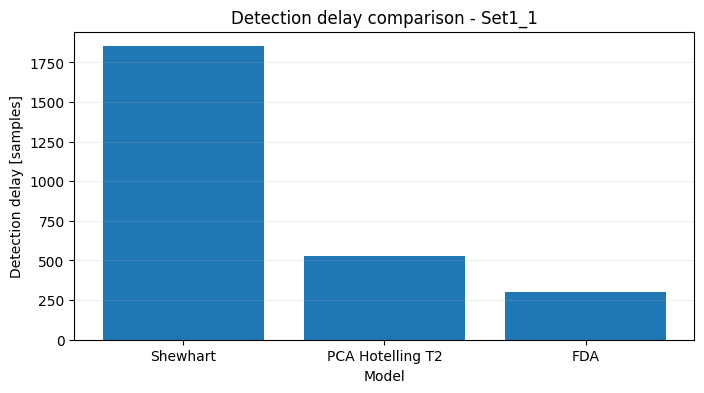

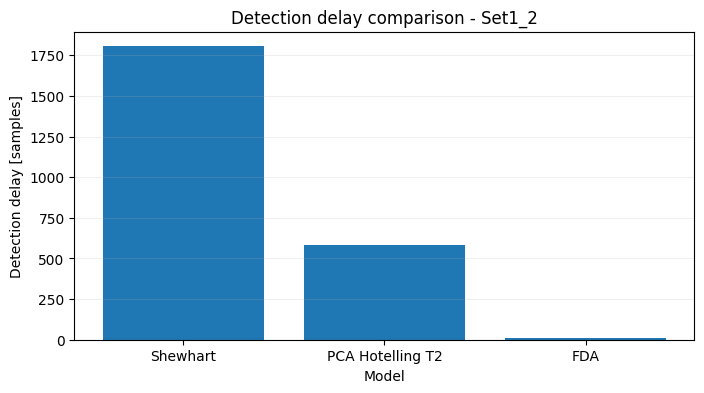

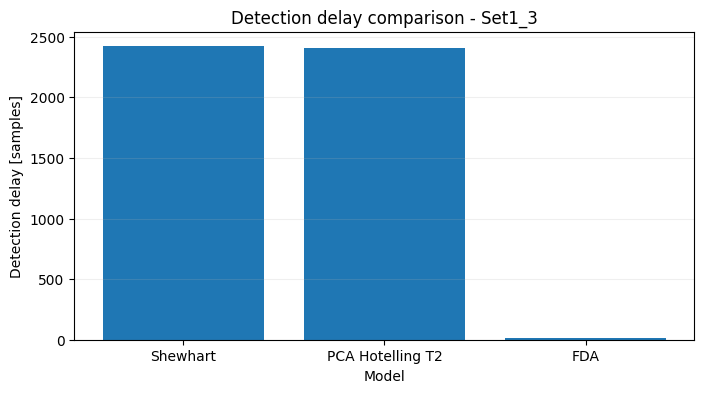

In [7]:
plot_df = comparison_df.copy()
plot_df["detection_delay"] = pd.to_numeric(
    plot_df["detection_delay"],
    errors="coerce",
)

for dataset_name in plot_df["Dataset"].unique():
    subset = plot_df[plot_df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 4))
    plt.bar(subset["Model"], subset["detection_delay"])
    plt.title(f"Detection delay comparison - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Detection delay [samples]")
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()